# AIML Project
## Detection of Phishing Websites using Machine Learning

**Student:** Priyanshu  
**Course:** Artificial Intelligence and Machine Learning  
**Dataset:** Phishing Website Dataset (Kaggle)

### Objective
To build a machine learning model that can classify websites as **phishing** or **legitimate** based on various website and URL features.

## 1. Introduction
Phishing is one of the most common cyber attacks where attackers create fake websites to steal sensitive information such as usernames, passwords, and financial data. Machine learning techniques can help detect phishing websites automatically by analyzing patterns in website features.

In this project, we use a supervised machine learning approach to train a model that can classify websites as phishing or legitimate.

## 2. Import Required Libraries

In [30]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

## 3. Load Dataset
Place the **phishing.csv** file in the same folder as this notebook.

In [31]:
data = pd.read_csv("phishing.csv")
data.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


## 4. Explore Dataset

In [32]:
print("Dataset Shape:", data.shape)
print("\nColumns:")
print(data.columns)
print("\nDataset Info:")
data.info()

Dataset Shape: (11054, 32)

Columns:
Index(['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//',
       'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon',
       'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL',
       'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL',
       'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick',
       'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording',
       'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage',
       'StatsReport', 'class'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             1105

## 5. Check Class Distribution

In [33]:
print(data["class"].value_counts())

class
 1    6157
-1    4897
Name: count, dtype: int64


## 6. Data Preprocessing
Remove unnecessary columns and separate features from the target variable.

In [34]:
data = data.drop("Index", axis=1)

X = data.drop("class", axis=1)
y = data["class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (11054, 30)
Target shape: (11054,)


## 7. Split Dataset into Training and Testing Sets

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8843
Testing samples: 2211


## 8. Train Random Forest Model

In [36]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 9. Random Forest Predictions

In [37]:
rf_predictions = rf_model.predict(X_test)

## 10. Random Forest Evaluation

In [38]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

pickle.dump(rf_model, open("phishing_model.pkl", "wb"))

Random Forest Accuracy: 0.9692446856625961

Classification Report:
              precision    recall  f1-score   support

          -1       0.97      0.96      0.96       976
           1       0.97      0.98      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211


Confusion Matrix:
[[ 937   39]
 [  29 1206]]


## 11. Train Decision Tree Model

In [39]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## 12. Decision Tree Predictions

In [40]:
dt_predictions = dt_model.predict(X_test)

## 13. Decision Tree Evaluation

In [41]:
dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))

Decision Tree Accuracy: 0.9601990049751243

Classification Report:
              precision    recall  f1-score   support

          -1       0.95      0.96      0.96       976
           1       0.97      0.96      0.96      1235

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211


Confusion Matrix:
[[ 936   40]
 [  48 1187]]


## 14. Feature Importance
This shows which features are most important for detecting phishing websites.

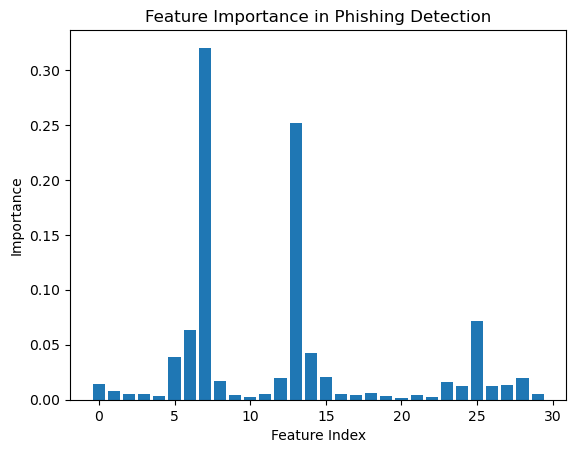

In [42]:
importance = rf_model.feature_importances_

plt.figure()
plt.bar(range(len(importance)), importance)
plt.title("Feature Importance in Phishing Detection")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

## 15. Test Prediction with Example

In [43]:
sample = X_test.iloc[0].values.reshape(1,-1)

prediction = rf_model.predict(sample)

if prediction[0] == 1:
    print("Prediction: Legitimate Website")
else:
    print("Prediction: Phishing Website")

Prediction: Phishing Website


C:\Users\patel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## 16. Conclusion
In this project, machine learning techniques were used to detect phishing websites based on website features. Both Random Forest and Decision Tree classifiers were trained and evaluated. The models achieved high accuracy in identifying phishing websites, demonstrating that machine learning can be an effective tool in improving cyber security systems.